# Volatility Calibration using Neural Network

In [12]:
import pandas as pd
import numpy as np
#from numba import jit
from joblib import Parallel, delayed
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import csv
import matplotlib.ticker as mtick
from numba import njit


## 1- Define the Monte Carlo pricer
Used to generate the synthetic data for the 1rst the NN calibration



In [2]:
# ------------------------------------------------------------------
# 1. Black-Scholes Helper Functions
# ------------------------------------------------------------------
def bs_call_price(S, K, T, r, vol):
    """Calculates the Black-Scholes price of a European Call option."""
    d1 = (np.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_volatility(target_price, S, K, T, r=0.0):
    """Inverts the Black-Scholes formula to find implied volatility using Brent's method."""
    # If the price is below intrinsic value, it violates arbitrage bounds; return a small floor vol.
    intrinsic = max(S - K, 0)
    if target_price <= intrinsic:
        return 0.001

    def objective_function(vol):
        return bs_call_price(S, K, T, r, vol) - target_price

    try:
        # Search for the volatility between 0.1% and 300%
        return brentq(objective_function, 1e-3, 3.0)
    except ValueError:
        # If the solver fails to converge, return a NaN or default
        return np.nan

import numpy as np
import math
from numba import njit, prange

# ------------------------------------------------------------------
# 1. Black-Scholes Helper Functions (NUMBA COMPATIBLES)
# ------------------------------------------------------------------
@njit(fastmath=True, cache=True)
def norm_cdf(x):
    """Approximation ultra-rapide de norm.cdf via math.erf"""
    return 0.5 * (1.0 + math.erf(x / 1.4142135623730951)) # divisé par sqrt(2)

@njit(fastmath=True, cache=True)
def bs_call_price_numba(S, K, T, r, vol):
    """Pricer Black-Scholes compatible Numba."""
    d1 = (math.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * math.sqrt(T))
    d2 = d1 - vol * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

@njit(fastmath=True, cache=True)
def implied_volatility_numba(target_price, S, K, T, r=0.0):
    """
    Remplace scipy.optimize.brentq par un solveur de dichotomie (Bisection) 
    entièrement compilable en code C via Numba.
    """
    intrinsic = max(S - K, 0.0)
    if target_price <= intrinsic:
        return 0.001

    # Recherche par dichotomie (très robuste, pas besoin de SciPy)
    low = 1e-3
    high = 3.0
    
    # 50 itérations suffisent largement pour converger à la précision float64
    for _ in range(50):
        mid = (low + high) / 2.0
        price_mid = bs_call_price_numba(S, K, T, r, mid)
        
        if price_mid > target_price:
            high = mid
        else:
            low = mid
            
    return (low + high) / 2.0

# ------------------------------------------------------------------
# 2. The Rough Bergomi Monte Carlo Simulator (OPTIMISÉ)
# ------------------------------------------------------------------
@njit(fastmath=True, cache=True)
def rough_bergomi_mc_pricer(params, maturities, strikes, S0=1.0, paths=10000, steps_per_year=100):
    
    # 1. Extract Parameters
    xi_array = params[:8]
    nu = params[8]
    rho = params[9]
    H = params[10]

    T_max = maturities[-1]
    total_steps = int(T_max * steps_per_year)
    dt = T_max / total_steps
    
    # Remplacement de np.linspace (parfois capricieux avec numba sur les types)
    time_grid = np.zeros(total_steps)
    for i in range(total_steps):
        time_grid[i] = dt * (i + 1)

    # 2. Map Piecewise Forward Variance (xi_0) to the time grid
    xi_t = np.zeros(total_steps)
    for i in range(total_steps):
        t = time_grid[i]
        # Recherche d'index compatible Numba
        bucket_idx = np.searchsorted(maturities, t)
        if bucket_idx >= len(xi_array):
            bucket_idx = len(xi_array) - 1
        xi_t[i] = xi_array[bucket_idx]

    # 3. Generate Correlated Brownian Motions
    # Note : Numba gère np.random.normal très bien
    dZ = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW_perp = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW = rho * dZ + math.sqrt(1.0 - rho**2) * dW_perp

# 4. Simulate the Volterra Process (Y_t) using a Riemann Sum
    Y = np.zeros((paths, total_steps))
    gamma_kernel = np.zeros(total_steps)
    for k in range(1, total_steps + 1):
        gamma_kernel[k-1] = ((k - 0.5) * dt)**(H - 0.5)

    sqrt_2H = math.sqrt(2.0 * H)
    
    # Remplacement du np.dot par une boucle pure C/Numba (0 allocation mémoire)
    for p in range(paths):
        for i in range(total_steps):
            sum_Z = 0.0
            for k in range(i + 1):
                sum_Z += dZ[p, k] * gamma_kernel[i - k]
            Y[p, i] = sqrt_2H * sum_Z

    # 5. Construct the Variance Process (V_t)
    t_2H = np.zeros(total_steps)
    for i in range(total_steps):
        t_2H[i] = time_grid[i]**(2.0 * H)
        
    V = np.zeros((paths, total_steps))
    for i in range(total_steps):
        for p in range(paths):
            V[p, i] = xi_t[i] * math.exp(nu * Y[p, i] - 0.5 * (nu**2) * t_2H[i])

    # 6. Construct the Stock Price Process (S_t)
    X = np.zeros((paths, total_steps + 1))
    for i in range(total_steps):
        for p in range(paths):
            dX = -0.5 * V[p, i] * dt + math.sqrt(V[p, i]) * dW[p, i]
            X[p, i+1] = X[p, i] + dX

    S = np.zeros((paths, total_steps + 1))
    for p in range(paths):
        for i in range(total_steps + 1):
            S[p, i] = S0 * math.exp(X[p, i])

    # 7. Apply the Spot Martingale Control Variate
    for i in range(1, total_steps + 1):
        mean_S = np.mean(S[:, i])
        for p in range(paths):
            S[p, i] = S[p, i] * (S0 / mean_S)

    # 8. Calculate Prices and Implied Volatilities for the Grid
    vol_grid = np.zeros((len(maturities), len(strikes)))

    for i in range(len(maturities)):
        T = maturities[i]
        step_idx = int(T * steps_per_year)
        S_T = S[:, step_idx]

        for j in range(len(strikes)):
            K = strikes[j]
            
            # Calcul du payoff et moyenne
            mc_price = 0.0
            for p in range(paths):
                mc_price += max(S_T[p] - K, 0.0)
            mc_price /= paths

            # Invert to find Implied Volatility via notre nouvelle fonction Numba
            iv = implied_volatility_numba(mc_price, S0, K, T, 0.0)
            vol_grid[i, j] = iv

    return vol_grid

## 2- Generate the synthetic Data for Calibration

In [3]:
# ==========================================
# 1. MOTEUR DE SIMULATION (COMPILÉ VIA NUMBA)
# ==========================================

def simulate_single_scenario(current_params, maturities, strikes, idx, total_samples):
    # Affiche l'avancement toutes les 200 simulations
    if idx % 1 == 0:
        print(f"🔄 Calcul en cours : Scénario {idx} / {total_samples}...")

    # L'appel utilise bien 15 000 chemins pour garantir la convergence du pricing
    simulated_vol_grid = rough_bergomi_mc_pricer(
        current_params,
        maturities,
        strikes,
        S0=1.0,
        paths=15000, 
        steps_per_year=100
    )
    return simulated_vol_grid.flatten()

# ==========================================
# 3. GÉNÉRATEUR PARALLÈLE DE DATASET
# ==========================================
def generate_synthetic_dataset_optimized(num_samples):
    maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
    strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])

    num_maturities = len(maturities)

    lower_bounds = [0.01] * num_maturities + [0.5, -0.95, 0.025]
    upper_bounds = [0.16] * num_maturities + [4.0, -0.1, 0.5]

    print("Génération des paramètres aléatoires...")
    X_parameters = np.random.uniform(lower_bounds, upper_bounds, size=(num_samples, len(lower_bounds)))

    # --- WARMUP NUMBA (CRUCIAL) ---
    print("🔥 Compilation de Numba en cours (Warm-up d'un scénario)...")
    _ = simulate_single_scenario(X_parameters[0], maturities, strikes, 0, 1)
    print("✅ Compilation terminée ! Lancement des vrais calculs...")

    start_time = time.time()

    # On retire nos propres prints et on laisse joblib gérer l'affichage (verbose=10)
    # batch_size=50 est un bon équilibre pour 15000 chemins
    Y_volatilities = Parallel(n_jobs=-1, verbose=10, batch_size=50)(
        delayed(simulate_single_scenario)(X_parameters[i], maturities, strikes, i, num_samples)
        for i in range(num_samples)
    )
    
    end_time = time.time()
    print(f"✅ Simulation totale terminée en {end_time - start_time:.2f} secondes !")

    param_columns = [f'xi_{m}' for m in maturities] + ['nu', 'rho', 'H']
    vol_columns = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]

    df_params = pd.DataFrame(X_parameters, columns=param_columns)
    df_vols = pd.DataFrame(Y_volatilities, columns=vol_columns)

    return pd.concat([df_params, df_vols], axis=1)

# ==========================================
# 4. EXÉCUTION DU SCRIPT
# ==========================================
if __name__ == '__main__':
    # On met 40000 comme recommandé par le papier pour la version finale
    dataset = generate_synthetic_dataset_optimized(num_samples=40000)
    
    print("\nAperçu du dataset généré :")
    print(dataset.head())
    
    # Sauvegarde
    filename = "rough_bergomi_training_data_optim.csv"
    dataset.to_csv(filename, index=False)
    print(f"\nDonnées sauvegardées dans '{filename}'")

Génération des paramètres aléatoires...
🔥 Compilation de Numba en cours (Warm-up d'un scénario)...
🔄 Calcul en cours : Scénario 0 / 1...
✅ Compilation terminée ! Lancement des vrais calculs...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 424 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 874 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done 1324 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 1874 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 2424 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 3074 tasks      | elapsed:  7.7min
[Parallel(n_jobs=-1)]: Done 3724 tasks      | elapsed:  9.2min
[Parallel(n_jobs=-1)]: Done 4474 tasks      | elapsed: 10.7min
[Parallel(n_jobs=-1)]: Done 5224 tasks      | elapsed: 12.1min
[Parallel(n_jobs=-1)]: Done 6074 tasks      | elapsed: 14.3min
[Parallel(n_jobs=-1)]: Done 6924 tasks      | elapsed: 16.0min
[Parallel(n_jobs=-1)]: Done 7874 tasks      | 

✅ Simulation totale terminée en 5668.98 secondes !

Aperçu du dataset généré :
     xi_0.1    xi_0.3    xi_0.6    xi_0.9    xi_1.2    xi_1.5    xi_1.8  \
0  0.121010  0.089658  0.032092  0.095032  0.078867  0.070559  0.109932   
1  0.106959  0.014857  0.139187  0.144122  0.137248  0.100424  0.107250   
2  0.104331  0.108323  0.140729  0.027067  0.073345  0.066790  0.015225   
3  0.040394  0.066685  0.097361  0.098828  0.043937  0.060295  0.054433   
4  0.013237  0.105806  0.139843  0.010551  0.020384  0.117858  0.098111   

     xi_2.0        nu       rho  ...  vol_T2.0_K0.6  vol_T2.0_K0.7  \
0  0.086277  0.591157 -0.604987  ...       0.330974       0.317297   
1  0.057930  3.112214 -0.236545  ...       0.309937       0.272010   
2  0.157774  0.554374 -0.418130  ...       0.283350       0.279929   
3  0.068121  1.287130 -0.811497  ...       0.350502       0.322238   
4  0.092704  3.584791 -0.279284  ...       0.297188       0.256189   

   vol_T2.0_K0.8  vol_T2.0_K0.9  vol_T2.0_K1.0  v

## 3- Train the NN
### a - Scale and normalize

In [ ]:
#numpy_dataset = dataset.to_numpy()
xx= numpy_dataset[:,:11]
yy= numpy_dataset[:,11:]

X_train, X_test, y_train, y_test = train_test_split(
    yy, xx, test_size=0.15, random_state=42)
scale = StandardScaler()
scale2=  StandardScaler()
y_train_transform = scale.fit_transform(y_train)
y_test_transform = scale.transform(y_test) # we use transform rather than fit_transform to ensure the same scaling is applied to test data
x_train_transform = scale2.fit_transform(X_train)
x_test_transform = scale2.transform(X_test)

def xinversetransform(x):
    return scale2.inverse_transform(x)

NameError: name 'train_test_split' is not defined

In [ ]:
# Upper and lower bounds used in the training set
ub=[0.16,0.16,0.16,0.16,0.16,0.16,0.16,0.16,4,0,0.5]
lb=[0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.5,-1,0.025]
def myscale(x):
    res=np.zeros(11)
    for i in range(11):
        res[i]=(x[i] - (ub[i] + lb[i])*0.5) * 2 / (ub[i] - lb[i])

    return res
def myinverse(x):
    res=np.zeros(11)
    for i in range(11):
        res[i]=x[i]*(ub[i] - lb[i]) *0.5 + (ub[i] + lb[i])*0.5

    return res

y_train_transform = np.array([myscale(y) for y in y_train])
y_test_transform = np.array([myscale(y) for y in y_test])

### b- Create the Neural Network

In [6]:
import keras
from keras.layers import Activation
from keras import backend as K
from keras.callbacks import EarlyStopping

keras.backend.set_floatx('float64')
input1 = keras.layers.Input(shape=(11,))
x1 = keras.layers.Dense(30,activation = 'elu')(input1)
x2=keras.layers.Dense(30,activation = 'elu')(x1)
x3=keras.layers.Dense(30,activation = 'elu')(x2)
x4=keras.layers.Dense(30,activation = 'elu')(x3)

x5=keras.layers.Dense(88,activation = 'linear')(x4)

modelGEN = keras.models.Model(inputs=input1, outputs=x5)
modelGEN.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 88)             │         2,728 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,878 (45.92 KB)

 Trainable params: 5,878 (45.92 KB)

 Non-trainable params: 0 (0.00 B)

### c- Fit the Neural Network

In [9]:
patience = 25
NumEpochs = 500

earlystop = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    mode="min",
    verbose=1,
    patience=patience
)

# Using the universally supported "mse" (Mean Squared Error)
modelGEN.compile(loss="mse", optimizer="adam")

modelGEN.fit(
    y_train_transform, 
    x_train_transform, 
    batch_size=32,
    validation_data=(y_test_transform, x_test_transform),
    epochs=NumEpochs, 
    verbose=True,
    shuffle=1,
    callbacks=[earlystop]
)


Epoch 1/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1978 - val_loss: 0.0652
Epoch 2/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0555 - val_loss: 0.0501
Epoch 3/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0451 - val_loss: 0.0428
Epoch 4/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0408 - val_loss: 0.0390
Epoch 5/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0383 - val_loss: 0.0380
Epoch 6/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0367 - val_loss: 0.0365
Epoch 7/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0352 - val_loss: 0.0356
Epoch 8/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0341 - val_loss: 0.0347
Epoch 9/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0332 - val_loss: 0.0353
Epoch 10/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0325 - val_loss: 0.0326
Epoch 11/500
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0319 - val_loss: 0.0326
Epoch 12/500
1063/1

In [10]:
# Save calibration results
modelGEN.save('my_rough_bergomi_model.keras')

In [11]:
# Open pre-saved results
from keras.models import load_model

modelGEN = load_model('my_rough_bergomi_model.keras')

In [12]:
# Store Parameters
NNParameters=[]
for i in range(1,len(modelGEN.layers)):
    NNParameters.append(modelGEN.layers[i].get_weights())

### d- Hardcore the Neural Network in NUMPY for performance improvement

In [13]:
NumLayers=4
NumParameters=11
def elu(x):
    #Careful function ovewrites x
    ind=(x<0)
    x[ind]=np.exp(x[ind])-1
    return x
def eluPrime(y):
    # we make a deep copy of input x
    x=np.copy(y)
    ind=(x<0)
    x[ind]=np.exp(x[ind])
    x[~ind]=1
    return x
def NeuralNetwork(x):
    input1=x
    for i in range(NumLayers):
        input1=np.dot(input1,NNParameters[i][0])+NNParameters[i][1]
        #Elu activation
        input1=elu(input1)
    #The output layer is linnear
    i+=1
    return np.dot(input1,NNParameters[i][0])+NNParameters[i][1]
def NeuralNetworkGradient(x):
    input1=x
    #Identity Matrix represents Jacobian with respect to initial parameters
    grad=np.eye(NumParameters)
    #Propagate the gradient via chain rule
    for i in range(NumLayers):
        input1=(np.dot(input1,NNParameters[i][0])+NNParameters[i][1])
        grad=(np.einsum('ij,jk->ik', grad, NNParameters[i][0]))
        #Elu activation
        grad*=eluPrime(input1)
        input1=elu(input1)
    #input1.append(np.dot(input1[i],NNParameters[i+1][0])+NNParameters[i+1][1])
    grad=np.einsum('ij,jk->ik',grad,NNParameters[i+1][0])
    #grad stores all intermediate Jacobians, however only the last one is used here as output
    return grad

### e- Visualise the results of the NN on the synthetic data

In [ ]:
# 1. Global Variables (Re-declared to guarantee they are in memory)
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
strikes_dim = len(strikes)

# 2. Correct 11-element boundaries
ub = [0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 4.0, 0.0, 0.5]
lb = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.5, -1.0, 0.025]

# 3. Scaling function
def myscale(x):
    res = np.zeros(11)
    for i in range(11):
        res[i] = (x[i] - (ub[i] + lb[i])*0.5) * 2 / (ub[i] - lb[i])
    return res

# 4. Inverse transform function (Fixed for the 2D requirement of StandardScaler)
def xinversetransform(x):
    # Reshape to 2D for sklearn, then extract the 1D result with [0]
    return scale2.inverse_transform(x.reshape(1, -1))[0]

# 5. The plotting function
def plot_func(xi0, nu, rho, H):
    # Duplicate xi0 eight times to cover all maturities, then append nu, rho, H
    full_params = np.array([xi0]*8 + [nu, rho, H])
    
    # Scale inputs and predict with Neural Network
    x0 = myscale(full_params)
    Smiles = xinversetransform(NeuralNetwork(x0))
    
    # Plotting
    plt.figure(1, figsize=(14,12))
    for i in range(8):
        plt.subplot(4, 4, i+1)
        plt.plot(np.log(strikes/1.0), Smiles[i*strikes_dim:(i+1)*strikes_dim], '*b', label="NN Approx")
        
        plt.ylim(0.1, 0.8)
        plt.title("Maturity=%1.2f " % maturities[i])
        plt.xlabel("log-moneyness")
        plt.ylabel("Implied vol")
        plt.legend()
        
    plt.tight_layout()
    plt.show()

# 6. The interactive widget
interact(plot_func, 
         xi0 = widgets.FloatSlider(value=0.04, min=0.01, max=0.16, step=0.01),
         nu  = widgets.FloatSlider(value=2.0, min=0.3, max=4.0, step=0.1),
         rho = widgets.FloatSlider(value=-0.7, min=-0.95, max=-0.1, step=0.05),
         H   = widgets.FloatSlider(value=0.1, min=0.025, max=0.5, step=0.05))

interactive(children=(FloatSlider(value=0.04, description='xi0', max=0.16, min=0.01, step=0.01), FloatSlider(v…

<function __main__.plot_func(xi0, nu, rho, H)>

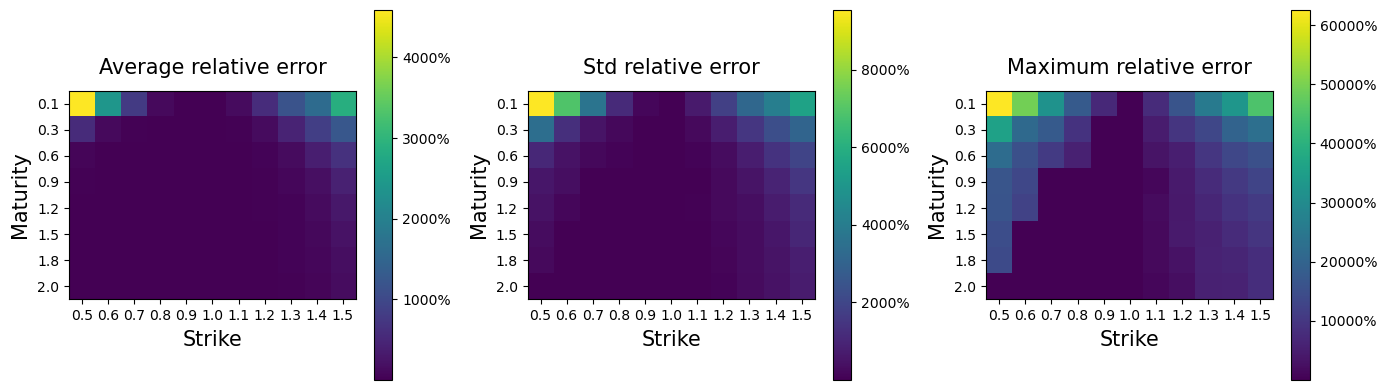

In [20]:
# Implied vol relative errors on test set

S0=1.
strikes_dim=len(strikes)
maturities_dim=len(maturities)
strikeslabel=np.round(np.linspace(strikes[0],strikes[-1],8),1)
maturitieslabel=np.array([0.1,0.2, 0.6, 1.5,1.8])
##### AVERAGE VALUES #######
X_sample = X_test
y_sample = y_test_transform

prediction=[xinversetransform(NeuralNetwork(y_sample[i])) for i in range(len(y_sample))]
plt.figure(1,figsize=(14,4))
ax=plt.subplot(1,3,1)
err = np.mean(100*np.abs((X_sample-prediction)/X_sample),axis = 0)
plt.title("Average relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())

ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)

ax=plt.subplot(1,3,2)
err = 100*np.std(np.abs((X_sample-prediction)/X_sample),axis = 0)
plt.title("Std relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())
ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)

ax=plt.subplot(1,3,3)
err = 100*np.max(np.abs((X_sample-prediction)/X_sample),axis = 0)
plt.title("Maximum relative error",fontsize=15,y=1.04)
plt.imshow(err.reshape(maturities_dim,strikes_dim))
plt.colorbar(format=mtick.PercentFormatter())
ax.set_xticks(np.linspace(0,len(strikes)-1,len(strikes)))
ax.set_xticklabels(strikes)
ax.set_yticks(np.linspace(0,len(maturities)-1,len(maturities)))
ax.set_yticklabels(maturities)
plt.xlabel("Strike",fontsize=15,labelpad=5)
plt.ylabel("Maturity",fontsize=15,labelpad=5)
plt.tight_layout()
plt.savefig('rBergomiTermStructureNNErrors.PNG', dpi=300)
plt.show()


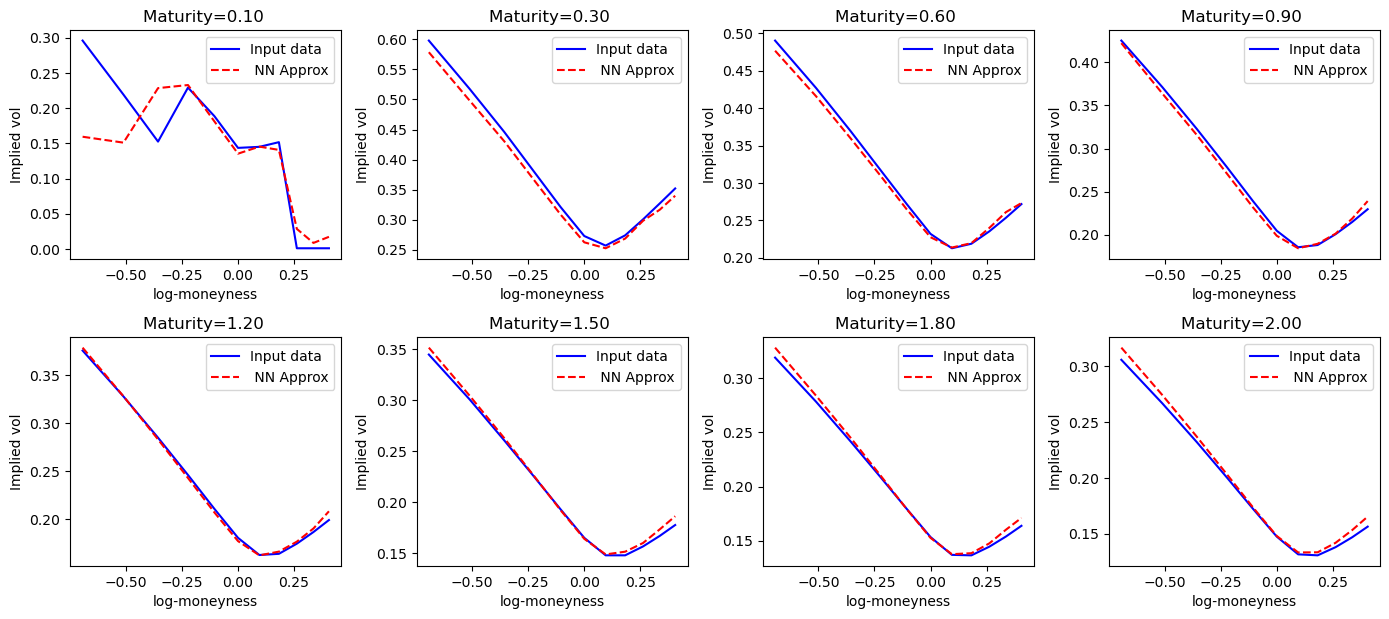

Model Parameters:  [ 0.02263457  0.14674967  0.06272988  0.04460515  0.01405728  0.04383611
  0.04144801  0.07785283  3.02343364 -0.28069066  0.47023928]


In [21]:
# Plot sample smiles



import scipy
S0=1.

sample_ind = 250
X_sample = X_test[sample_ind]
y_sample = y_test_transform[sample_ind]

prediction=xinversetransform(NeuralNetwork(y_sample))
plt.figure(1,figsize=(14,12))
for i in range(maturities_dim):
    plt.subplot(4,4,i+1)

    plt.plot(np.log(strikes/S0),X_sample[i*strikes_dim:(i+1)*strikes_dim],'b',label="Input data")
    plt.plot(np.log(strikes/S0),prediction[i*strikes_dim:(i+1)*strikes_dim],'--r',label=" NN Approx")


    plt.title("Maturity=%1.2f "%maturities[i])
    plt.xlabel("log-moneyness")
    plt.ylabel("Implied vol")

    plt.legend()
plt.tight_layout()
plt.show()

print("Model Parameters: ",myinverse(y_sample))

## 4- Test the NN on market data
### a. Use gradient methods for optimization

In [22]:
def CostFunc(x,sample_ind):
    return np.sum(np.power((NeuralNetwork(x)-x_test_transform[sample_ind]),2))
def Jacobian(x,sample_ind):
    return 2*np.sum((NeuralNetwork(x)-x_test_transform[sample_ind])*NeuralNetworkGradient(x),axis=1)
#Cost Function for Levenberg Marquardt
def CostFuncLS(x,sample_ind):
    return (NeuralNetwork(x)-x_test_transform[sample_ind])
def JacobianLS(x,sample_ind):
    return NeuralNetworkGradient(x).T


### b. Results for Levenberg-Maquart algorithm

In [23]:
import scipy.optimize

# 1. Clean Storage Containers
CalibratedParameters = []
Timing = []

# The starting guess (all 0s in the scaled space)
init = np.zeros(11)

print("Starting Levenberg-Marquardt Calibration...")

# 2. The 5,000 Scenario Loop (LM Only)
for i in range(5000):
    disp = str(i+1) + "/5000"
    print(disp, end="\r")

    # Levenberg-Marquardt
    start = time.perf_counter() # Updated from time.clock()
    I = scipy.optimize.least_squares(CostFuncLS, init, JacobianLS, args=(i,), gtol=1E-10)
    end = time.perf_counter()

    # Save the un-scaled real-world parameters and the elapsed time
    CalibratedParameters.append(myinverse(I.x))
    Timing.append(end - start)

print(f"\nCalibration Complete!")
print(f"Average LM Calibration Time: {np.mean(Timing)*1000:.2f} Milliseconds")


Starting Levenberg-Marquardt Calibration...
5000/5000
Calibration Complete!
Average LM Calibration Time: 8.12 Milliseconds


In [1]:
# 3. Plotting the Relative Errors for the 11 Parameters
titles=["$\\xi_1$","$\\xi_2$","$\\xi_3$","$\\xi_4$","$\\xi_5$","$\\xi_6$","$\\xi_7$","$\\xi_8$","$\\nu$","$\\rho$","$H$"]
average=np.zeros([11,5000])
fig=plt.figure(figsize=(10,14))

for u in range(11):
    ax=plt.subplot(6,2,u+1)

    for i in range(5000):
        y = y_test[i][u]

        # Note the updated indexing: [i][u] instead of the old [i][3][u]
        calibrated_guess = CalibratedParameters[i][u]

        # Calculate and plot relative error
        plt.plot(y, 100 * np.abs(calibrated_guess - y) / np.abs(y), 'b*')
        average[u,i] = np.abs(calibrated_guess - y) / np.abs(y)

    # Formatting the graphs
    plt.title(titles[u], fontsize=20)
    plt.ylabel('relative Error', fontsize=15)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.tick_params(axis='both', which='minor', labelsize=15)

    # Calculate and display Average and Median stats on the graph
    avg_error = np.mean(100 * average[u,:])
    med_error = np.quantile(100 * average[u,:], 0.5)
    plt.text(0.5, 0.8, f'Average: {avg_error:1.2f}%\n Median:   {med_error:1.2f}% ',
             horizontalalignment='center', verticalalignment='center',
             transform=ax.transAxes, fontsize=15)

    print(f"average {titles[u]} = {avg_error:.2f}%")

# Save and show the final image
plt.tight_layout()
plt.savefig('rBergomiTermStructureParameterRelativeErrors.png', dpi=300)
plt.show()

NameError: name 'np' is not defined

In [5]:
import pandas as pd
import numpy as np
import glob
from scipy.interpolate import griddata
import re

# ==========================================
# 1. SETUP TARGET GRID
# ==========================================
target_maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
target_moneyness = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
grid_T, grid_K = np.meshgrid(target_maturities, target_moneyness)
vol_columns = [f'vol_T{t}_K{k}' for t in target_maturities for k in target_moneyness]

def parse_french_date(date_str):
    fr_to_en = {
        'janvier': 'january', 'février': 'february', 'mars': 'march',
        'avril': 'april', 'mai': 'may', 'juin': 'june',
        'juillet': 'july', 'août': 'august', 'septembre': 'september',
        'octobre': 'october', 'novembre': 'november', 'décembre': 'december'
    }
    date_str = date_str.lower()
    for fr, en in fr_to_en.items():
        date_str = date_str.replace(fr, en)
    return pd.to_datetime(date_str)

# ==========================================
# 2. ÉTAPE A: TOUT LIRE ET FUSIONNER
# ==========================================
file_list = glob.glob("spx_quotedata_*.csv")
print(f"Trouvé {len(file_list)} fichiers. Lecture et fusion en cours...")

all_raw_data = []

for file in file_list:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            header_text = "".join([f.readline() for _ in range(5)])
            
        spot_match = re.search(r'Last:\s*([\d\.]+)', header_text)
        S0 = float(spot_match.group(1)) if spot_match else None
        
        date_match = re.search(r'Date:\s*(.*?)\s*(?:à|,)', header_text)
        if date_match:
            quote_date = parse_french_date(date_match.group(1).strip())
        else:
            quote_date = None
            
        if S0 is None or quote_date is None:
            continue

        df = pd.read_csv(file, skiprows=3)
        df['Expiration Date'] = pd.to_datetime(df['Expiration Date'])
        df['T'] = (df['Expiration Date'] - quote_date).dt.days / 365.25
        df['Moneyness'] = df['Strike'] / S0
        
        put_iv_col = 'IV.1' if 'IV.1' in df.columns else df.columns[-5]
        df['Target_IV'] = np.where(df['Strike'] < S0, df[put_iv_col], df['IV'])
        
        clean_data = df[(df['Target_IV'] > 0) & (df['T'] > 0.02)].copy()
        
        # On ajoute la date et le spot pour pouvoir grouper plus tard
        clean_data['Quote_Date'] = quote_date
        clean_data['Spot'] = S0
        
        all_raw_data.append(clean_data)
        
    except Exception as e:
        pass

# Concaténation de tous les fichiers (Avril, Mai, Juin...) en un seul DataFrame géant
master_raw_df = pd.concat(all_raw_data, ignore_index=True)
print(f"Fusion réussie : {len(master_raw_df)} options uniques chargées.\n")

# ==========================================
# 3. ÉTAPE B: GROUPER PAR DATE ET INTERPOLER
# ==========================================
master_dataset = []

# On groupe par date de cotation (Quote_Date). 
# Si vos 19 fichiers ont été téléchargés le même jour, il n'y aura qu'un seul groupe contenant tout !
for quote_date, group in master_raw_df.groupby('Quote_Date'):
    print(f"Génération de la surface pour la date : {quote_date.date()}...")
    
    S0 = group['Spot'].mean() # Moyenne au cas où il y ait de très légères variations
    
    points = group[['T', 'Moneyness']].values
    values = group['Target_IV'].values
    
    # INTERPOLATION EN DEUX ÉTAPES (Le correctif anti-NaN)
    # 1. Linéaire pour la précision au centre des données
    interp_linear = griddata(points, values, (grid_T, grid_K), method='linear')
    # 2. Nearest (le plus proche) pour combler les bords vides
    interp_nearest = griddata(points, values, (grid_T, grid_K), method='nearest')
    
    # 3. On combine : On prend Linear, et on remplace les NaNs par Nearest
    interpolated_surface = np.where(np.isnan(interp_linear), interp_nearest, interp_linear).T
    
    market_target_88 = interpolated_surface.flatten()
    
    # Vérification finale
    if np.isnan(market_target_88).any():
        print(f"⚠️ Échec extrême : données insuffisantes même après extrapolation pour {quote_date.date()}")
        continue
        
    daily_record = {'Date': quote_date, 'Spot': S0}
    for col_name, vol_val in zip(vol_columns, market_target_88):
        daily_record[col_name] = vol_val
        
    master_dataset.append(daily_record)
    print(f"✅ Surface 8x11 complétée avec succès !")

# ==========================================
# 4. SAUVEGARDE
# ==========================================
if master_dataset:
    df_final = pd.DataFrame(master_dataset)
    df_final = df_final.sort_values('Date').reset_index(drop=True)
    df_final.to_csv("SPX_Historical_8x11_Surfaces.csv", index=False)
    print(f"\n🎉 Terminé ! {len(df_final)} surfaces de volatilité complètes ont été sauvegardées.")
else:
    print("Aucune surface valide générée.")

Trouvé 19 fichiers. Lecture et fusion en cours...
Fusion réussie : 6189 options uniques chargées.

Génération de la surface pour la date : 2026-04-10...
✅ Surface 8x11 complétée avec succès !

🎉 Terminé ! 1 surfaces de volatilité complètes ont été sauvegardées.


In [ ]:
import scipy.optimize
import pandas as pd
import numpy as np

# 1. Charger la vraie surface du marché qu'on vient de créer
real_market_df = pd.read_csv("SPX_Historical_8x11_Surfaces.csv")

# 2. Extraire les 88 volatilités (les colonnes 0 et 1 sont Date et Spot)
real_vols = real_market_df.iloc[0, 2:].values.astype(float)

# 3. Mettre à l'échelle les volatilités avec le scaler de votre réseau de neurones
# scale2 attend une matrice 2D, donc on utilise reshape(1, -1)
real_vols_scaled = scale2.transform(real_vols.reshape(1, -1))[0]

# 4. Redéfinir la fonction de coût pour cibler notre vraie donnée
def CostFuncLS_Market(x):
    return (NeuralNetwork(x) - real_vols_scaled)
    
def JacobianLS_Market(x):
    # La dérivée (Jacobienne) ne dépend que du réseau, c'est la même qu'avant !
    return NeuralNetworkGradient(x).T

# 5. Lancer l'optimisation Levenberg-Marquardt
print("🔍 Calibration sur les données réelles du S&P 500 en cours...")
init_guess = np.zeros(11) # On commence au milieu de notre espace de paramètres

result = scipy.optimize.least_squares(
    CostFuncLS_Market, 
    init_guess, 
    JacobianLS_Market, 
    gtol=1E-10
)

# 6. Récupérer les vrais paramètres
# On utilise votre fonction myinverse pour remettre les paramètres à leur vraie échelle
calibrated_params = myinverse(result.x)

# 7. Affichage des résultats !
target_maturities = [0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0]

print("\n✅ Calibration réussie !")
print(f"Date de cotation : {real_market_df['Date'].iloc[0]}")
print(f"S&P 500 Spot     : {real_market_df['Spot'].iloc[0]}")
print("-" * 40)
print("🎯 PARAMÈTRES ROUGH BERGOMI CALIBRÉS :")
print(f"H   (Exposant de Hurst) = {calibrated_params[10]:.4f}")
print(f"nu  (Vol of Vol)        = {calibrated_params[8]:.4f}")
print(f"rho (Corrélation Spot/Vol)= {calibrated_params[9]:.4f}")
print("-" * 40)
print("📈 Courbe de Variance Initiale (Forward Variance) :")
for i, t in enumerate(target_maturities):
    print(f"  xi({t} ans) = {calibrated_params[i]:.4f}")

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [20]:
maturities = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0])

# Strikes (Moneyness) : 20 points (très denses entre 0.8 et 1.2)
strikes = np.array([
    0.3, 0.4, 0.5, 0.6, 0.7, 
    0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 
    1.3, 1.4, 1.5, 1.6, 1.7, 1.8
])

def parse_french_date(date_str):
    fr_to_en = {'janvier': 'january', 'février': 'february', 'mars': 'march', 'avril': 'april', 
                'mai': 'may', 'juin': 'june', 'juillet': 'july', 'août': 'august', 
                'septembre': 'september', 'octobre': 'october', 'novembre': 'november', 'décembre': 'december'}
    date_str = date_str.lower()
    for fr, en in fr_to_en.items(): date_str = date_str.replace(fr, en)
    return pd.to_datetime(date_str)

grid_T, grid_K = np.meshgrid(maturities, strikes)
vol_columns = [f'vol_T{t}_K{k}' for t in maturities for k in strikes]

file_list = glob.glob("spx_quotedata_*.csv")
print(f"Extraction des données marché ({len(file_list)} fichiers trouvés)...")

all_raw_data = []
for file in file_list:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            header_text = "".join([f.readline() for _ in range(5)])
        S0 = float(re.search(r'Last:\s*([\d\.]+)', header_text).group(1))
        quote_date = parse_french_date(re.search(r'Date:\s*(.*?)\s*(?:à|,)', header_text).group(1).strip())
        
        df = pd.read_csv(file, skiprows=3)
        df['T'] = (pd.to_datetime(df['Expiration Date']) - quote_date).dt.days / 365.25
        df['Moneyness'] = df['Strike'] / S0
        put_iv_col = 'IV.1' if 'IV.1' in df.columns else df.columns[-5]
        df['Target_IV'] = np.where(df['Strike'] < S0, df[put_iv_col], df['IV'])
        
        clean_data = df[(df['Target_IV'] > 0) & (df['T'] > 0.02)].copy()
        clean_data['Quote_Date'] = quote_date
        clean_data['Spot'] = S0
        all_raw_data.append(clean_data)
    except: pass

master_dataset = []
if all_raw_data:
    master_raw_df = pd.concat(all_raw_data, ignore_index=True)
    for quote_date, group in master_raw_df.groupby('Quote_Date'):
        S0 = group['Spot'].mean()
        points, values = group[['T', 'Moneyness']].values, group['Target_IV'].values
        
        # Interpolation 2D robuste
        interp_linear = griddata(points, values, (grid_T, grid_K), method='linear')
        interp_nearest = griddata(points, values, (grid_T, grid_K), method='nearest')
        interpolated_surface = np.where(np.isnan(interp_linear), interp_nearest, interp_linear).T
        
        market_target_88 = interpolated_surface.flatten()
        if not np.isnan(market_target_88).any():
            daily_record = {'Date': quote_date, 'Spot': S0}
            for col_name, vol_val in zip(vol_columns, market_target_88): daily_record[col_name] = vol_val
            master_dataset.append(daily_record)

    if master_dataset:
        pd.DataFrame(master_dataset).sort_values('Date').to_csv("SPX_Historical_8x11_Surfaces.csv", index=False)
        print("✅ Données marché traitées et sauvegardées !")

Extraction des données marché (19 fichiers trouvés)...
✅ Données marché traitées et sauvegardées !


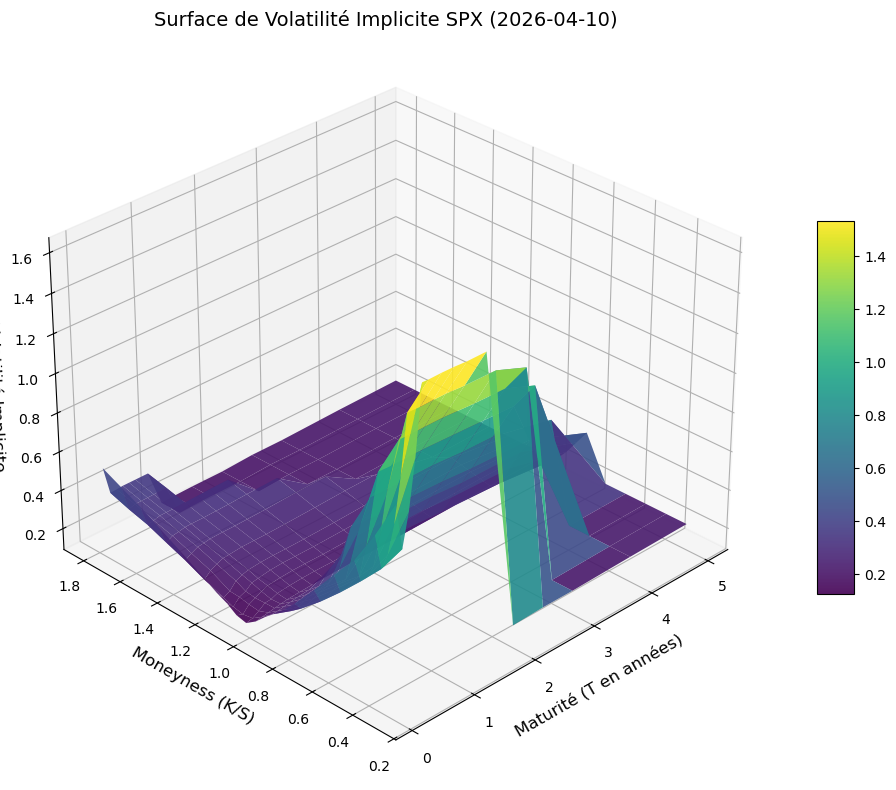

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. On récupère la dernière surface calculée (ou on charge le CSV)
# Si vous venez de lancer le script, on utilise 'market_target_88'
# Sinon, on charge la première ligne du CSV généré :
try:
    df_plot = pd.read_csv("SPX_Historical_8x11_Surfaces.csv")
    vols_flat = df_plot.iloc[0, 2:].values.astype(float)
    current_date = df_plot['Date'].iloc[0]
except:
    # Cas où le fichier n'est pas encore sur le disque
    vols_flat = market_target_88
    current_date = "Dernière extraction"

# 2. Reshape des 88 points en grille (8 maturités x 11 strikes)
# Important : l'ordre doit correspondre à votre boucle 'vol_columns'
Z = vols_flat.reshape(len(maturities), len(strikes))

# 3. Création des axes pour le plot (X = Maturités, Y = Moneyness)
X, Y = np.meshgrid(maturities, strikes)
# On transpose Z pour qu'il corresponde aux dimensions de la meshgrid (11, 8)
Z_plot = Z.T

# 4. Création du graphique 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# On trace la surface
surf = ax.plot_surface(X, Y, Z_plot, cmap='viridis', edgecolor='none', alpha=0.9)

# Personnalisation
ax.set_title(f'Surface de Volatilité Implicite SPX ({current_date})', fontsize=14)
ax.set_xlabel('Maturité (T en années)', fontsize=12)
ax.set_ylabel('Moneyness (K/S)', fontsize=12)
ax.set_zlabel('Volatilité Implicite', fontsize=12)

# Ajouter une barre de couleur
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# Ajuster l'angle de vue pour bien voir le Skew et la structure à terme
ax.view_init(elev=30, azim=-135)

plt.tight_layout()
plt.show()